# KK1 notebook

## Imports och data loading

After downloading the data from seaborn, saving it locally to as csv file and reading from the local file.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penguins = sns.load_dataset("penguins")
penguins.to_csv("data/raw/penguins_raw.csv", index=False)

df = pd.read_csv("data/raw/penguins_raw.csv")

## Exploretory data analysis (EDA)

In [45]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Dataset inspection

### Amount of rows and columns

In [44]:
df.shape


(344, 7)

### Datatypes 

In [43]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


### Quick summry of the values in the data set

In [42]:
df.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Missing values 

In [62]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Data cleaning

 Dropping all the nan values because even after dropping it has still a good chuck left to experement with. i went from 344 to 333 rows.  
 the missing values in dataset is probably because of incomple messurments during data collection. 


In [48]:
df_clean = df.dropna()

### Amount of duplicate data in the dataset

In [47]:
df_clean.duplicated().sum()

np.int64(0)

### Checking the transition of raw and clean data

In [52]:
print("raw data: ", df.shape)
print("clean data: ", df_clean.shape)

raw data:  (344, 7)
clean data:  (333, 7)


### Saving the clean data to csv 

In [53]:
df_clean.to_csv("data/processed/penguins_clean.csv", index=False)

## What is the distribution of sex in the dataset?


sex
Male      168
Female    165
Name: count, dtype: int64


Text(0.5, 1.0, 'Male penguins are slightly more in amount vs Female penguins in the dataset')

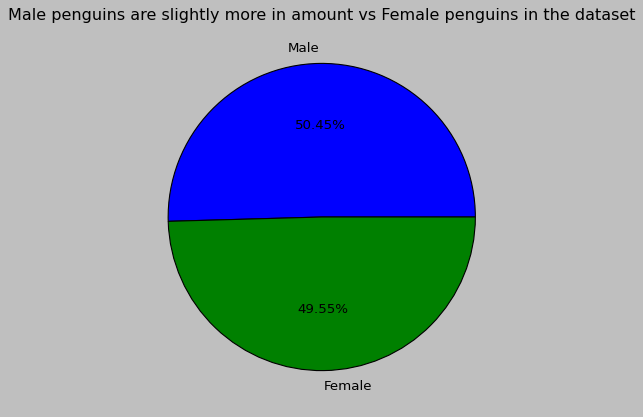

In [82]:
sex_count = df_clean["sex"].value_counts()
print(sex_count)

fig, ax = plt.subplots()

ax.pie(
  sex_count,
  labels=sex_count.index,
  autopct="%1.2f%%"
)

ax.set_title("Male penguins are slightly more in amount vs Female penguins in the dataset")


I chose pie chart for this visualization because it is intiutivly easy to see the difference and the percentage makes understanding even better. Chosing a heatmap here would be a bad choice because heat map is better for corralation between stuff. I could have chosen bar chart as well it would work just fine i prefer pie chart more here. 

## How are species spreed across the different islands?

In [84]:
island = df_clean["island"].value_counts()
print(island)

species = df_clean["species"].value_counts()
print(species)

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [ ]:
biscoe = df_clean[df_clean["island"] == "Biscoe"]
dream = df_clean[df_clean["island"] == "Dream"]
torgersen = df_clean[df_clean["island"] == "Torgersen"]
print(biscoe)
print(dream)
print(torgersen)

    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
20   Adelie  Biscoe            37.8           18.3              174.0   
21   Adelie  Biscoe            37.7           18.7              180.0   
22   Adelie  Biscoe            35.9           19.2              189.0   
23   Adelie  Biscoe            38.2           18.1              185.0   
24   Adelie  Biscoe            38.8           17.2              180.0   
..      ...     ...             ...            ...                ...   
338  Gentoo  Biscoe            47.2           13.7              214.0   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
20        3400.0  Female  
21        3600.0    Male  
22        3800.0  Female  
23        3950.

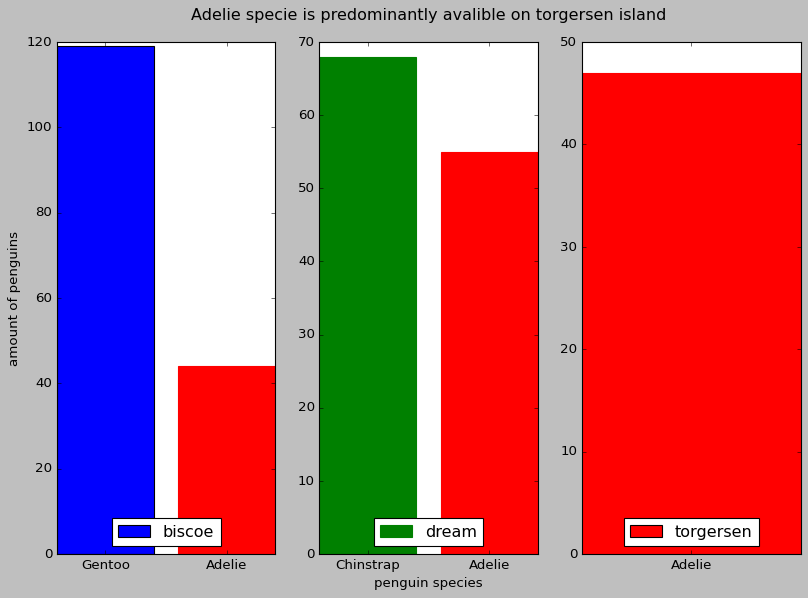

In [171]:
fig, ax = plt.subplots(1,3, figsize = (12,8))
a1, a2, a3 = ax.flat


biscoe_counts = biscoe.species.value_counts()
bars = a1.bar(
    biscoe_counts.index,
    biscoe_counts.values,
    label="biscoe",
)
a1.legend( loc="lower center")
a1.set_ylabel("amount of penguins")
bars[1].set_color("red")



dream_counts = dream.species.value_counts()
bars = a2.bar(
    dream_counts.index,
    dream_counts.values,
    label="dream",
)
bars[1].set_color("red")
bars[0].set_color("green")
a2.legend( loc="lower center")
a2.set_title("Adelie specie is predominantly avalible on torgersen island", pad=20)
a2.set_xlabel("penguin species")


torgersen_counts = torgersen.species.value_counts()
bars = a3.bar(
    torgersen_counts.index,
    torgersen_counts.values,
    label="torgersen",
    color="red"
)
a3.legend( loc="lower center")
bars[0].set_color("red")





I chose bar chart here because it is good for comparing and moreover it is very clear when it comes to axes what they are and what the bars mean. the only thing that could be a little bit ambigous might be the names of the islands, a person who is not familier with the dataset might not know that the labels are name of the islands. To companset for the island name ambiguiti i have explicitly called out one of the islands name. Histogram could also work here but histograms bins are not optimal for this kind of comparison and it gets visually worse to read the chart. 

## How does the body mass differ between all penguins?

Text(0.5, 1.0, 'Gento species have more body mass than both Adelie and Chinstrap')

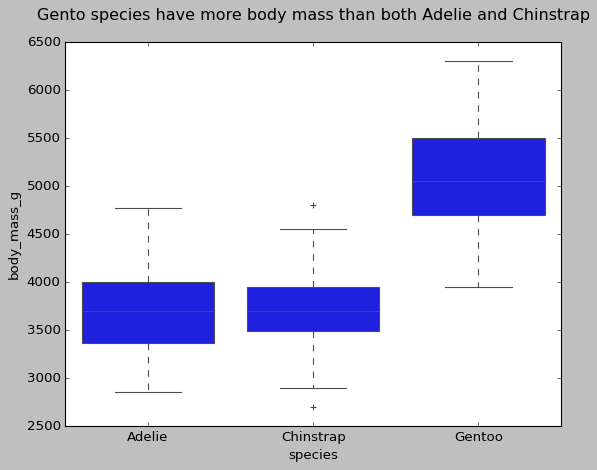

In [182]:
fig, ax = plt.subplots()

sns.boxplot(
  data = df_clean,
  x="species",
  y="body_mass_g",
)

ax.set_title("Gento species have more body mass than both Adelie and Chinstrap", pad=20)

I chose boxplot because it shows the spred of body mass for each species side by side and there medien and outliers, it is a great way of getting a fast overview of general stats between different groups. I used seabord boxplot because it is more convinient and it looks better. It is defenitly possible to do the same with matplotlib as well it includes just some extra steps. 

## Which island has the heaviest penguins on average?

Text(0.5, 0, 'islands')

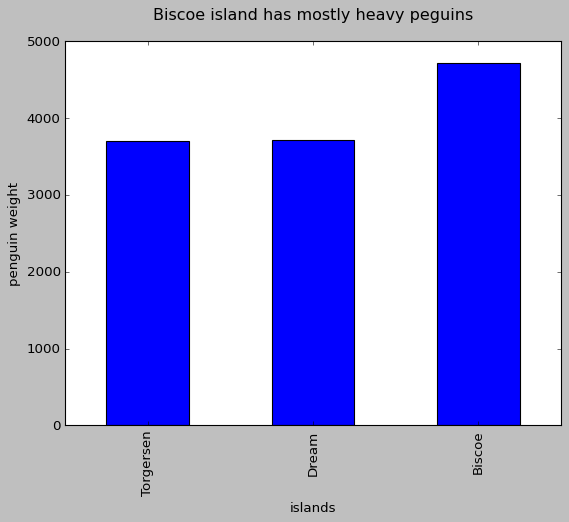

In [188]:
avg_mass = df_clean.groupby("island")["body_mass_g"].mean().sort_values()

fig, ax = plt.subplots()

avg_mass.plot(kind="bar")
ax.set_title("Biscoe island has mostly heavy peguins", pad=20)
ax.set_ylabel("penguin weight")
ax.set_xlabel("islands")